# Experimentation with the Dijkstra algorithm and matplotlib to display the smell gradient

## The smell map

We use the Dijsktra algorithm available in the NotworkX library to calculate the smell gradiant based on the distance to the target.

In [1]:
import networkx as nx

def smell_map(maze):
    rows, cols = maze.shape

    # --- Build the graph ---
    G = nx.Graph()
    index = lambda r, c: (r, c)  # use (row, col) tuples as nodes
    
    # Connect all adjacent (non-wall) cells
    for r in range(rows):
        for c in range(cols):
            if maze[r, c] == 1:
                continue  # skip walls
            for dr, dc in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] != 1:
                    G.add_edge(index(r, c), index(nr, nc), weight=1)
    
    # --- Identify target cells ---
    targets = [(r, c) for r in range(rows) for c in range(cols) if maze[r, c] == 5]
    
    # --- Compute shortest distances from each cell to the nearest target ---
    distance_map = np.full((rows, cols), 100) #np.inf)
    
    for target in targets:
        lengths = nx.single_source_dijkstra_path_length(G, target)
        for (r, c), dist in lengths.items():
            distance_map[r, c] = min(distance_map[r, c], dist)
    
    # Replace walls with NaN for display clarity
    # distance_map[maze == 1] = np.nan
    return distance_map


## Test of the smell gradiant display

[[100 100 100 100 100 100 100 100 100 100 100 100 100]
 [100   7   6   5   4   3   2   1   2 100  14  15 100]
 [100   6   5   4   3   2   1   0   1 100  13  14 100]
 [100   7   6   5   4   3   2   1   2 100  12  13 100]
 [100   8   7   6   5   4   3   2   3 100  11  12 100]
 [100   9   8   7   6   5   4   3   4 100  10  11 100]
 [100  10   9   8   7   6   5   4   5 100   9  10 100]
 [100  11  10   9   8   7   6   5   6   7   8   9 100]
 [100  12  11  10   9   8   7   6   7   8   9  10 100]
 [100 100 100 100 100 100 100 100 100 100 100 100 100]]


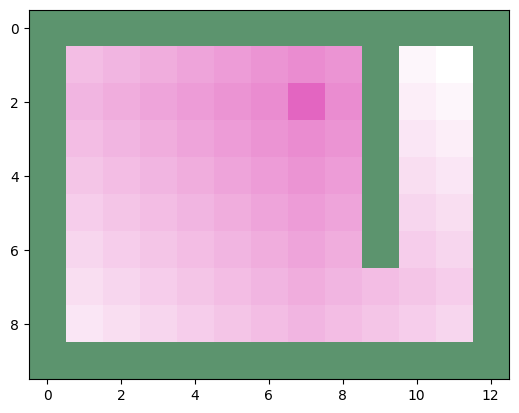

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex, to_rgb
rgb_target = np.array(to_rgb("#E365C1"))
brighter_target =  to_hex(rgb_target + (1 - rgb_target) * 0.2)
cmap_smell = LinearSegmentedColormap.from_list("smell_gradiant", [brighter_target, "#ffffff"])

grid = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 5, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
])

smells = smell_map(grid)
print(smells)
fig, ax = plt.subplots()
colors = ["#D6D6D6", '#5C946E', '#FAE2DB', '#535865', "#F93943", "#E365C1"]
colors_rgb = np.array([to_rgb(c) for c in colors])
ax.imshow(colors_rgb[grid])
masked_smell = np.ma.masked_where(grid > 0, smells)
max_smell = np.max(masked_smell)
ax.imshow(masked_smell, cmap=cmap_smell, vmin=0, vmax=np.max(masked_smell))
